In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install -q evaluate jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 44.4 MB/s eta 0:00:0000:0100:01


In [3]:
# ============================================================
# PART 1 : ENVIRONMENT SETUP
# Wav2Vec2 CTC Fine-Tuning on AMI
# Kaggle Tesla P100
# Transformers 4.55.4
# ============================================================

import os
import gc
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchaudio

import datasets
import transformers
import evaluate

from datasets import load_dataset, Audio
from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2ForCTC,
    Trainer,
    TrainingArguments,
    set_seed,
    EarlyStoppingCallback,
)

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Seed
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

set_seed(SEED)

# ------------------------------------------------------------
# GPU
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_FP16 = torch.cuda.is_available()

print("=" * 60)
print("Wav2Vec2 CTC Fine-Tuning")
print("=" * 60)

print("Torch         :", torch.__version__)
print("Transformers  :", transformers.__version__)
print("Datasets      :", datasets.__version__)
print("Evaluate      :", evaluate.__version__)

print("\nDevice :", DEVICE)

if torch.cuda.is_available():

    print("GPU :", torch.cuda.get_device_name(0))

    print(
        "Memory :",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3,2),
        "GB"
    )

# ------------------------------------------------------------
# Global Constants
# ------------------------------------------------------------

MODEL_NAME = "facebook/wav2vec2-base-960h"

SAMPLING_RATE = 16000

MAX_INPUT_LENGTH = 15 * SAMPLING_RATE

MIN_INPUT_LENGTH = 400

OUTPUT_DIR = "/kaggle/working/wav2vec2_ami"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("\nOutput Directory")
print(OUTPUT_DIR)

print("\nEnvironment Ready")

print("=" * 60)
print("PART 1 COMPLETED SUCCESSFULLY")
print("=" * 60)

Wav2Vec2 CTC Fine-Tuning
Torch         : 2.10.0+cu128
Transformers  : 5.0.0
Datasets      : 5.0.0
Evaluate      : 0.4.6

Device : cuda
GPU : Tesla T4
Memory : 14.56 GB

Output Directory
/kaggle/working/wav2vec2_ami

Environment Ready
PART 1 COMPLETED SUCCESSFULLY


Loading AMI Meeting Corpus


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

ihm/train-00000-of-00042.parquet:   0%|          | 0.00/296M [00:00<?, ?B/s]

...

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

✓ Dataset Loaded Successfully
✓ Audio Resampled to 16 kHz

Dataset Statistics
----------------------------------------
Training Samples   : 10850
Validation Samples : 13098
Test Samples       : 12643

Dataset Features
----------------------------------------
{'meeting_id': Value('string'), 'audio_id': Value('string'), 'text': Value('string'), 'audio': Audio(sampling_rate=16000, decode=True, num_channels=None, stream_index=None), 'begin_time': Value('float32'), 'end_time': Value('float32'), 'microphone_id': Value('string'), 'speaker_id': Value('string')}

Available Keys
dict_keys(['meeting_id', 'audio_id', 'text', 'audio', 'begin_time', 'end_time', 'microphone_id', 'speaker_id'])

Meeting ID : EN2001a
Speaker ID : MEO069

Transcript
IF YOU IF YOU S. S. H. AND THEY HAVE THIS BIG WARNING ABOUT DOING NOTHING AT ALL IN THE GATEWAY MACHINE

Sampling Rate : 16000
Audio Length  : 67360
Duration      : 4.21 seconds


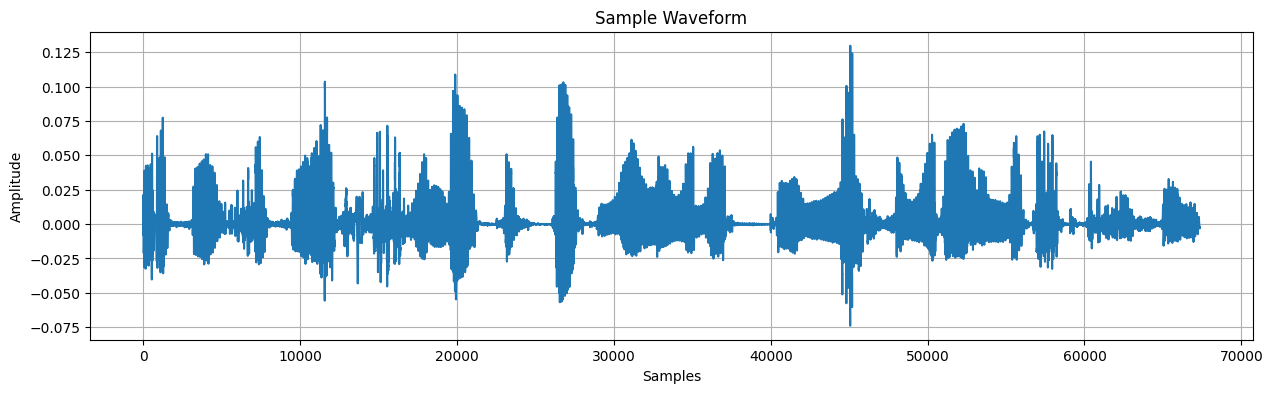


Audio Statistics
----------------------------------------
Minimum : -0.073913574
Maximum : 0.1296997
Mean    : -3.215491e-05
Std     : 0.01312359

PART 2 COMPLETED SUCCESSFULLY


In [4]:
# ============================================================
# PART 2 : LOAD AMI DATASET
# Official Dataset : edinburghcstr/ami
# IHM Configuration
# ============================================================

from datasets import load_dataset, Audio
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("Loading AMI Meeting Corpus")
print("=" * 60)

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

train_dataset = load_dataset(
    "edinburghcstr/ami",
    "ihm",
    split="train[:10%]"
)

validation_dataset = load_dataset(
    "edinburghcstr/ami",
    "ihm",
    split="validation"
)

test_dataset = load_dataset(
    "edinburghcstr/ami",
    "ihm",
    split="test"
)

print("✓ Dataset Loaded Successfully")

# ------------------------------------------------------------
# Cast Audio to 16kHz
# ------------------------------------------------------------

train_dataset = train_dataset.cast_column(
    "audio",
    Audio(sampling_rate=16000)
)

validation_dataset = validation_dataset.cast_column(
    "audio",
    Audio(sampling_rate=16000)
)

test_dataset = test_dataset.cast_column(
    "audio",
    Audio(sampling_rate=16000)
)

print("✓ Audio Resampled to 16 kHz")

# ------------------------------------------------------------
# Dataset Statistics
# ------------------------------------------------------------

print("\nDataset Statistics")
print("-" * 40)

print("Training Samples   :", len(train_dataset))
print("Validation Samples :", len(validation_dataset))
print("Test Samples       :", len(test_dataset))

# ------------------------------------------------------------
# Dataset Features
# ------------------------------------------------------------

print("\nDataset Features")
print("-" * 40)

print(train_dataset.features)

# ------------------------------------------------------------
# Display First Sample
# ------------------------------------------------------------

sample = train_dataset[0]

print("\nAvailable Keys")
print(sample.keys())

print("\nMeeting ID :", sample["meeting_id"])
print("Speaker ID :", sample["speaker_id"])

print("\nTranscript")
print(sample["text"])

# ------------------------------------------------------------
# Audio Information
# ------------------------------------------------------------

audio = sample["audio"]

print("\nSampling Rate :", audio["sampling_rate"])
print("Audio Length  :", len(audio["array"]))

duration = len(audio["array"]) / audio["sampling_rate"]

print(f"Duration      : {duration:.2f} seconds")

# ------------------------------------------------------------
# Plot Waveform
# ------------------------------------------------------------

plt.figure(figsize=(15,4))
plt.plot(audio["array"])
plt.title("Sample Waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Audio Statistics
# ------------------------------------------------------------

signal = np.asarray(audio["array"])

print("\nAudio Statistics")
print("-" * 40)

print("Minimum :", signal.min())
print("Maximum :", signal.max())
print("Mean    :", signal.mean())
print("Std     :", signal.std())

print("\n" + "=" * 60)
print("PART 2 COMPLETED SUCCESSFULLY")
print("=" * 60)

AMI DATASET EXPLORATION

Audio Duration Statistics
----------------------------------------
Minimum : 0.06 sec
Maximum : 14.95 sec
Average : 2.98 sec
Median  : 2.12 sec

Transcript Statistics
----------------------------------------
Minimum Words : 1
Maximum Words : 50
Average Words : 9.97
Median Words  : 7.50

Unique Speakers : 20
Unique Meetings : 9


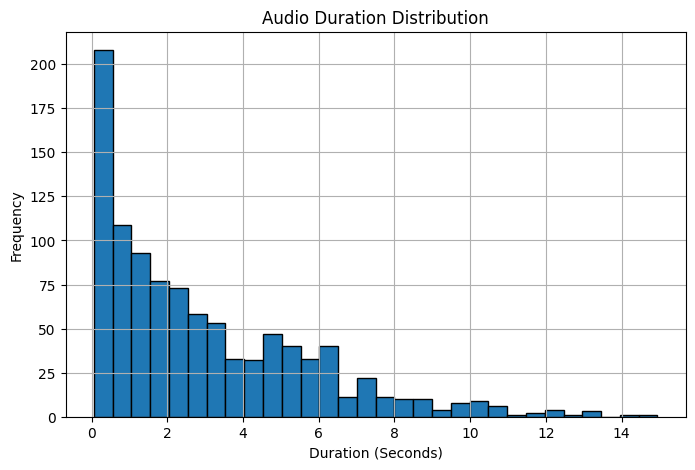

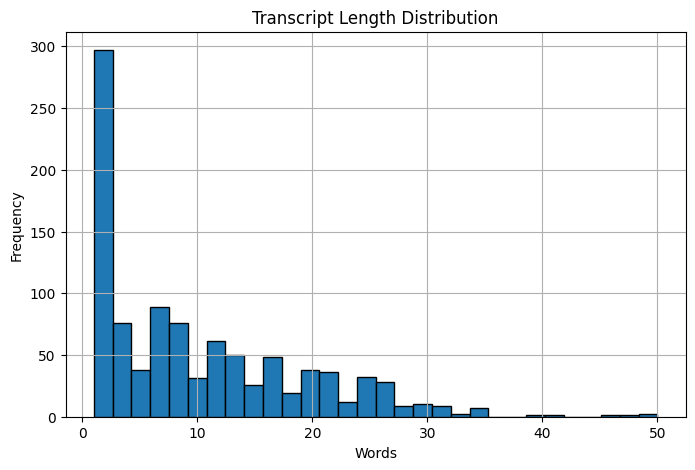

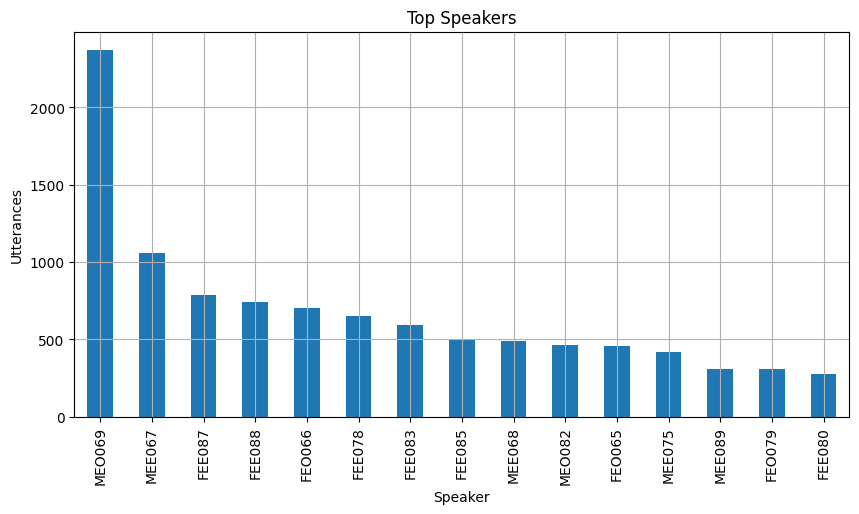

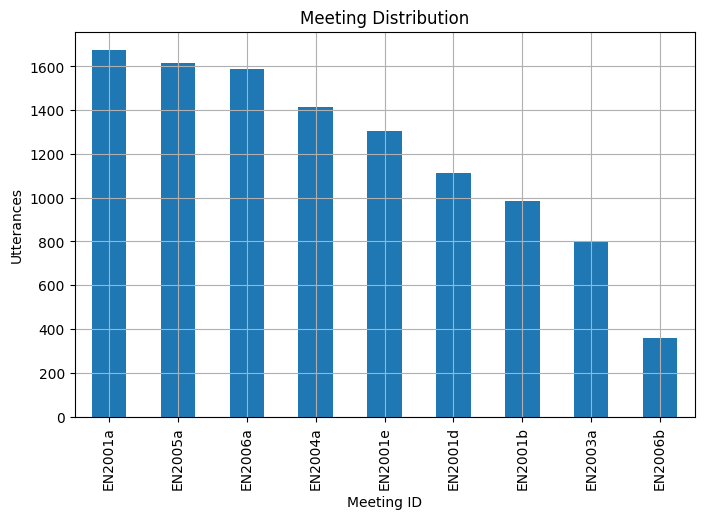


Random Training Samples

Sample : 10550
--------------------------------------------------
Meeting  : EN2006b
Speaker  : FEE087
Duration : 3.5 sec

Transcript
FROM I THINK SHOULD BE IN THERE

Sample : 3325
--------------------------------------------------
Meeting  : EN2001d
Speaker  : MEO069
Duration : 0.73 sec

Transcript
OKAY

Sample : 8084
--------------------------------------------------
Meeting  : EN2005a
Speaker  : FEE085
Duration : 2.29 sec

Transcript
ARE WE SUPPOSED TO COUNT TO TEN OR SOMETHING

Sample : 3753
--------------------------------------------------
Meeting  : EN2001d
Speaker  : MEE068
Duration : 2.21 sec

Transcript
YEAH I WAS WANTING TO TALK ABOUT THE SEARCH

Sample : 4607
--------------------------------------------------
Meeting  : EN2001e
Speaker  : MEE068
Duration : 0.24 sec

Transcript
HUH

PART 3 COMPLETED SUCCESSFULLY


In [5]:
# ============================================================
# PART 3 : DATASET EXPLORATION
# AMI Meeting Corpus
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("AMI DATASET EXPLORATION")
print("=" * 60)

# ------------------------------------------------------------
# Audio Duration Statistics
# ------------------------------------------------------------

durations = []

for sample in train_dataset.select(range(min(1000, len(train_dataset)))):

    audio = sample["audio"]

    duration = len(audio["array"]) / audio["sampling_rate"]

    durations.append(duration)

durations = np.array(durations)

print("\nAudio Duration Statistics")
print("-" * 40)

print(f"Minimum : {durations.min():.2f} sec")
print(f"Maximum : {durations.max():.2f} sec")
print(f"Average : {durations.mean():.2f} sec")
print(f"Median  : {np.median(durations):.2f} sec")

# ------------------------------------------------------------
# Transcript Statistics
# ------------------------------------------------------------

text_lengths = []

for sample in train_dataset.select(range(min(1000, len(train_dataset)))):

    text_lengths.append(
        len(sample["text"].split())
    )

text_lengths = np.array(text_lengths)

print("\nTranscript Statistics")
print("-" * 40)

print(f"Minimum Words : {text_lengths.min()}")
print(f"Maximum Words : {text_lengths.max()}")
print(f"Average Words : {text_lengths.mean():.2f}")
print(f"Median Words  : {np.median(text_lengths):.2f}")

# ------------------------------------------------------------
# Speaker Statistics
# ------------------------------------------------------------

speaker_df = pd.DataFrame(train_dataset)

print("\nUnique Speakers :", speaker_df["speaker_id"].nunique())

# ------------------------------------------------------------
# Meeting Statistics
# ------------------------------------------------------------

print("Unique Meetings :", speaker_df["meeting_id"].nunique())

# ------------------------------------------------------------
# Duration Histogram
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(
    durations,
    bins=30,
    edgecolor="black"
)

plt.title("Audio Duration Distribution")
plt.xlabel("Duration (Seconds)")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# Transcript Histogram
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(
    text_lengths,
    bins=30,
    edgecolor="black"
)

plt.title("Transcript Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# Speaker Distribution
# ------------------------------------------------------------

speaker_df["speaker_id"].value_counts().head(15).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Speakers")
plt.xlabel("Speaker")
plt.ylabel("Utterances")
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# Meeting Distribution
# ------------------------------------------------------------

speaker_df["meeting_id"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Meeting Distribution")
plt.xlabel("Meeting ID")
plt.ylabel("Utterances")
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# Random Samples
# ------------------------------------------------------------

print("\nRandom Training Samples")
print("=" * 60)

random_indices = np.random.choice(
    len(train_dataset),
    5,
    replace=False
)

for idx in random_indices:

    sample = train_dataset[int(idx)]

    audio = sample["audio"]

    duration = len(audio["array"]) / audio["sampling_rate"]

    print(f"\nSample : {idx}")
    print("-"*50)

    print("Meeting  :", sample["meeting_id"])
    print("Speaker  :", sample["speaker_id"])
    print("Duration :", round(duration,2),"sec")

    print("\nTranscript")
    print(sample["text"])

print("\n" + "=" * 60)
print("PART 3 COMPLETED SUCCESSFULLY")
print("=" * 60)

In [6]:
# ============================================================
# PART 4 : LOAD WAV2VEC2 MODEL
# Official Facebook Wav2Vec2 Base
# Stable Configuration
# ============================================================

from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
import torch

print("=" * 60)
print("Loading Official Wav2Vec2 Model")
print("=" * 60)

# ------------------------------------------------------------
# Model Name
# ------------------------------------------------------------

MODEL_NAME = "facebook/wav2vec2-base-960h"

# ------------------------------------------------------------
# Load Processor
# ------------------------------------------------------------

processor = Wav2Vec2Processor.from_pretrained(
    MODEL_NAME
)

print("✓ Processor Loaded")

# ------------------------------------------------------------
# Load Model
# ------------------------------------------------------------

model = Wav2Vec2ForCTC.from_pretrained(
    MODEL_NAME
)

print("✓ Model Loaded")

# ------------------------------------------------------------
# IMPORTANT CONFIGURATION
# ------------------------------------------------------------

model.config.ctc_loss_reduction = "mean"

model.config.ctc_zero_infinity = True

model.config.pad_token_id = processor.tokenizer.pad_token_id

model.config.vocab_size = len(processor.tokenizer)

model.config.use_cache = False

print("✓ CTC Configuration Updated")

# ------------------------------------------------------------
# Freeze Feature Encoder
# ------------------------------------------------------------

model.freeze_feature_encoder()

print("✓ Feature Encoder Frozen")

# ------------------------------------------------------------
# Move Model to GPU
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

print(f"\nUsing Device : {device}")

# ------------------------------------------------------------
# Parameter Statistics
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nModel Statistics")
print("-" * 50)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

# ------------------------------------------------------------
# Vocabulary Information
# ------------------------------------------------------------

print("\nVocabulary Information")
print("-" * 50)

print("Vocabulary Size :", len(processor.tokenizer))

print("Pad Token       :", processor.tokenizer.pad_token)

print("Pad Token ID    :", processor.tokenizer.pad_token_id)

print("Word Delimiter  :", processor.tokenizer.word_delimiter_token)

print("Blank Token ID  :", model.config.pad_token_id)

# ------------------------------------------------------------
# Audio Information
# ------------------------------------------------------------

print("\nAudio Configuration")
print("-" * 50)

print(
    "Sampling Rate :",
    processor.feature_extractor.sampling_rate
)

print(
    "Feature Size  :",
    processor.feature_extractor.feature_size
)

print(
    "Return Attention Mask :",
    processor.feature_extractor.return_attention_mask
)

# ------------------------------------------------------------
# Model Configuration
# ------------------------------------------------------------

print("\nModel Configuration")
print("-" * 50)

print("Hidden Size        :", model.config.hidden_size)

print("Hidden Layers      :", model.config.num_hidden_layers)

print("Attention Heads    :", model.config.num_attention_heads)

print("CTC Reduction      :", model.config.ctc_loss_reduction)

print("Zero Infinity      :", model.config.ctc_zero_infinity)

print("LayerDrop          :", model.config.layerdrop)

print("Final Dropout      :", model.config.final_dropout)

print("Mask Time Prob     :", model.config.mask_time_prob)

print("Mask Feature Prob  :", model.config.mask_feature_prob)

print("Gradient Checkpoint:", model.is_gradient_checkpointing)

print("\n" + "=" * 60)
print("PART 4 COMPLETED SUCCESSFULLY")
print("=" * 60)

Loading Official Wav2Vec2 Model


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

...

✓ Processor Loaded


model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Model Loaded
✓ CTC Configuration Updated
✓ Feature Encoder Frozen

Using Device : cuda

Model Statistics
--------------------------------------------------
Total Parameters     : 94,396,320
Trainable Parameters : 90,195,872

Vocabulary Information
--------------------------------------------------
Vocabulary Size : 32
Pad Token       : <pad>
Pad Token ID    : 0
Word Delimiter  : |
Blank Token ID  : 0

Audio Configuration
--------------------------------------------------
Sampling Rate : 16000
Feature Size  : 1
Return Attention Mask : False

Model Configuration
--------------------------------------------------
Hidden Size        : 768
Hidden Layers      : 12
Attention Heads    : 12
CTC Reduction      : mean
Zero Infinity      : True
LayerDrop          : 0.1
Final Dropout      : 0.1
Mask Time Prob     : 0.05
Mask Feature Prob  : 0.0
Gradient Checkpoint: False

PART 4 COMPLETED SUCCESSFULLY


In [7]:
# ============================================================
# PART 5 : DATA PREPROCESSING
# AMI Meeting Corpus
# Stable Version (Transformers 4.55.4)
# ============================================================

import re
import numpy as np

print("=" * 60)
print("Preparing Dataset")
print("=" * 60)

# ------------------------------------------------------------
# Text Cleaning
# ------------------------------------------------------------

def clean_text(text):

    text = text.upper()

    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\[.*?\]", "", text)
    text = re.sub(r"\(.*?\)", "", text)

    text = re.sub(r"[^A-Z' ]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()


# ------------------------------------------------------------
# Prepare Dataset
# ------------------------------------------------------------

def prepare_dataset(batch):

    audio = batch["audio"]

    speech = np.asarray(
        audio["array"],
        dtype=np.float32
    )

    # Remove NaN / Inf
    speech = np.nan_to_num(
        speech,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # Clip values
    speech = np.clip(
        speech,
        -1.0,
        1.0
    )

    # Skip empty audio
    if len(speech) == 0:
        speech = np.zeros(1600, dtype=np.float32)

    # --------------------------------------------------------
    # Audio Features
    # --------------------------------------------------------

    batch["input_values"] = processor(
        speech,
        sampling_rate=16000
    ).input_values[0]

    batch["input_length"] = len(batch["input_values"])

    # --------------------------------------------------------
    # Clean Transcript
    # --------------------------------------------------------

    text = clean_text(batch["text"])

    # Skip empty transcript
    if len(text) == 0:
        text = "UNKNOWN"

    batch["text"] = text

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    labels = processor.tokenizer(
        text,
        add_special_tokens=False
    ).input_ids

    # Skip empty labels
    if len(labels) == 0:
        labels = [
            processor.tokenizer.pad_token_id
        ]

    batch["labels"] = labels

    return batch


# ------------------------------------------------------------
# Apply Preprocessing
# ------------------------------------------------------------

print("\nProcessing Training Dataset...")

train_dataset = train_dataset.map(
    prepare_dataset,
    desc="Preparing Train"
)

print("\nProcessing Validation Dataset...")

validation_dataset = validation_dataset.map(
    prepare_dataset,
    desc="Preparing Validation"
)

print("\nProcessing Test Dataset...")

test_dataset = test_dataset.map(
    prepare_dataset,
    desc="Preparing Test"
)

# ------------------------------------------------------------
# Length Filtering
# ------------------------------------------------------------

MAX_INPUT_LENGTH = 15 * 16000
MIN_INPUT_LENGTH = 400

def length_filter(batch):

    return (
        MIN_INPUT_LENGTH
        <= batch["input_length"]
        <= MAX_INPUT_LENGTH
    )


train_dataset = train_dataset.filter(
    length_filter,
    desc="Filtering Train"
)

validation_dataset = validation_dataset.filter(
    length_filter,
    desc="Filtering Validation"
)

test_dataset = test_dataset.filter(
    length_filter,
    desc="Filtering Test"
)

# ------------------------------------------------------------
# Verify Dataset
# ------------------------------------------------------------

print("\nDataset Summary")
print("-" * 50)

print("Training Samples   :", len(train_dataset))
print("Validation Samples :", len(validation_dataset))
print("Test Samples       :", len(test_dataset))

sample = train_dataset[0]

print("\nExample Sample")
print("-" * 50)

print("Transcript :")
print(sample["text"])

print("\nInput Length :", sample["input_length"])

print("Label Length :", len(sample["labels"]))

print("\nFirst 20 Labels")
print(sample["labels"][:20])

print("\nAudio Range")
print(
    np.min(sample["input_values"]),
    np.max(sample["input_values"])
)

print("\nContains NaN :", np.isnan(sample["input_values"]).any())
print("Contains Inf :", np.isinf(sample["input_values"]).any())

print("\n" + "=" * 60)
print("PART 5 COMPLETED SUCCESSFULLY")
print("=" * 60)

Preparing Dataset

Processing Training Dataset...


Preparing Train:   0%|          | 0/10850 [00:00<?, ? examples/s]


Processing Validation Dataset...


Preparing Validation:   0%|          | 0/13098 [00:00<?, ? examples/s]


Processing Test Dataset...


Preparing Test:   0%|          | 0/12643 [00:00<?, ? examples/s]

Filtering Train:   0%|          | 0/10850 [00:00<?, ? examples/s]

Filtering Validation:   0%|          | 0/13098 [00:00<?, ? examples/s]

Filtering Test:   0%|          | 0/12643 [00:00<?, ? examples/s]


Dataset Summary
--------------------------------------------------
Training Samples   : 10823
Validation Samples : 13092
Test Samples       : 12610

Example Sample
--------------------------------------------------
Transcript :
IF YOU IF YOU S S H AND THEY HAVE THIS BIG WARNING ABOUT DOING NOTHING AT ALL IN THE GATEWAY MACHINE

Input Length : 67360
Label Length : 100

First 20 Labels
[10, 20, 4, 22, 8, 16, 4, 10, 20, 4, 22, 8, 16, 4, 12, 4, 12, 4, 11, 4]

Audio Range
-5.6280317306518555 9.882526397705078

Contains NaN : False
Contains Inf : False

PART 5 COMPLETED SUCCESSFULLY


In [8]:
from datasets import DatasetDict

dataset = train_dataset.train_test_split(
    test_size=0.1,
    seed=42
)

train_dataset = dataset["train"]
eval_dataset = dataset["test"]

print(train_dataset)
print(eval_dataset)

Dataset({
    features: ['meeting_id', 'audio_id', 'text', 'audio', 'begin_time', 'end_time', 'microphone_id', 'speaker_id', 'input_values', 'input_length', 'labels'],
    num_rows: 9740
})
Dataset({
    features: ['meeting_id', 'audio_id', 'text', 'audio', 'begin_time', 'end_time', 'microphone_id', 'speaker_id', 'input_values', 'input_length', 'labels'],
    num_rows: 1083
})


In [9]:
# ============================================================
# PART 6 : DATA COLLATOR
# Dynamic Padding for Wav2Vec2 CTC
# Stable Version (Transformers 4.55.4)
# ============================================================

from dataclasses import dataclass
from typing import Dict, List, Union
import torch

print("=" * 60)
print("Creating Data Collator")
print("=" * 60)

# ============================================================
# Data Collator
# ============================================================

@dataclass
class DataCollatorCTCWithPadding:

    processor: Wav2Vec2Processor
    padding: Union[bool, str] = True

    def __call__(self, features):

        # ----------------------------------------------------
        # Audio Features
        # ----------------------------------------------------

        input_features = [
            {"input_values": feature["input_values"]}
            for feature in features
        ]

        # ----------------------------------------------------
        # Label Features
        # ----------------------------------------------------

        label_features = [
            {"input_ids": feature["labels"]}
            for feature in features
        ]

        # ----------------------------------------------------
        # Pad Audio
        # ----------------------------------------------------

        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt"
        )

        # ----------------------------------------------------
        # Pad Labels
        # ----------------------------------------------------

        labels_batch = self.processor.tokenizer.pad(
            label_features,
            padding=self.padding,
            return_tensors="pt"
        )

        # ----------------------------------------------------
        # Replace Padding with -100
        # ----------------------------------------------------

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch["attention_mask"] != 1,
            -100
        )

        batch["labels"] = labels.long()

        # ----------------------------------------------------
        # Safety Checks
        # ----------------------------------------------------

        batch["input_values"] = torch.nan_to_num(
            batch["input_values"],
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        ).float()

        return batch


# ============================================================
# Initialize Data Collator
# ============================================================

data_collator = DataCollatorCTCWithPadding(
    processor=processor,
    padding=True
)

print("✓ Data Collator Created")

# ============================================================
# Test Data Collator
# ============================================================

sample_batch = [
    train_dataset[i]
    for i in range(2)
]

batch = data_collator(sample_batch)

print("\nBatch Information")
print("-" * 50)

print("Input Shape :", batch["input_values"].shape)
print("Label Shape :", batch["labels"].shape)

print("\nData Types")
print("-" * 50)

print("Input :", batch["input_values"].dtype)
print("Labels:", batch["labels"].dtype)

print("\nNaN Check")
print("-" * 50)

print("Input NaN :", torch.isnan(batch["input_values"]).any().item())
print("Label NaN :", torch.isnan(batch["labels"].float()).any().item())

print("\nInput Range")
print("-" * 50)

print("Minimum :", batch["input_values"].min().item())
print("Maximum :", batch["input_values"].max().item())

print("\nPadding Check")
print("-" * 50)

print("Ignored Tokens (-100):",
      (batch["labels"] == -100).sum().item())

print("\nFirst Sample Labels")
print(batch["labels"][0][:40])

print("\n" + "=" * 60)
print("PART 6 COMPLETED SUCCESSFULLY")
print("=" * 60)

Creating Data Collator
✓ Data Collator Created

Batch Information
--------------------------------------------------
Input Shape : torch.Size([2, 33760])
Label Shape : torch.Size([2, 17])

Data Types
--------------------------------------------------
Input : torch.float32
Labels: torch.int64

NaN Check
--------------------------------------------------
Input NaN : False
Label NaN : False

Input Range
--------------------------------------------------
Minimum : -6.821040153503418
Maximum : 6.890761852264404

Padding Check
--------------------------------------------------
Ignored Tokens (-100): 1

First Sample Labels
tensor([  18,   11,    7,    6,    4,   14,    8,    4,   22,    8,   16,    4,
          17,    5,    7,    9, -100])

PART 6 COMPLETED SUCCESSFULLY


In [10]:
# ============================================================
# PART 7 : EVALUATION METRICS
# WER + CER
# Stable Version (Transformers 4.55.4)
# ============================================================

import numpy as np
import evaluate

print("=" * 60)
print("Loading Evaluation Metrics")
print("=" * 60)

# ------------------------------------------------------------
# Load Metrics
# ------------------------------------------------------------

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

print("✓ WER Metric Loaded")
print("✓ CER Metric Loaded")


# ------------------------------------------------------------
# Compute Metrics
# ------------------------------------------------------------

def compute_metrics(pred):

    logits = pred.predictions

    # Trainer may return tuple
    if isinstance(logits, tuple):
        logits = logits[0]

    pred_ids = np.argmax(logits, axis=-1)

    label_ids = pred.label_ids.copy()

    # Replace ignored labels
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    # Decode predictions
    pred_str = processor.batch_decode(
        pred_ids,
        group_tokens=True
    )

    # Decode references
    label_str = processor.batch_decode(
        label_ids,
        group_tokens=False
    )

    # Remove leading/trailing spaces
    pred_str = [x.strip() for x in pred_str]
    label_str = [x.strip() for x in label_str]

    wer = wer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    cer = cer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    return {
        "wer": float(wer),
        "cer": float(cer)
    }


print("✓ compute_metrics() Ready")


# ------------------------------------------------------------
# Greedy Decoder
# ------------------------------------------------------------

def greedy_decode(logits):

    if isinstance(logits, tuple):
        logits = logits[0]

    pred_ids = np.argmax(logits, axis=-1)

    predictions = processor.batch_decode(
        pred_ids,
        group_tokens=True
    )

    return predictions


print("✓ Greedy Decoder Ready")


# ------------------------------------------------------------
# Test Metrics
# ------------------------------------------------------------

sample = train_dataset[0]

decoded = processor.decode(sample["labels"])

print("\nSample Transcript")
print("-" * 60)
print(decoded)

print("\nMetrics Ready")

print("\n" + "=" * 60)
print("PART 7 COMPLETED SUCCESSFULLY")
print("=" * 60)

Loading Evaluation Metrics


✓ WER Metric Loaded
✓ CER Metric Loaded
✓ compute_metrics() Ready
✓ Greedy Decoder Ready

Sample Transcript
------------------------------------------------------------
WHAT DO YOU MEAN

Metrics Ready

PART 7 COMPLETED SUCCESSFULLY


In [11]:
# ============================================================
# CREATE TRAIN / EVAL SPLIT
# ============================================================

dataset_split = train_dataset.train_test_split(
    test_size=0.10,
    seed=42
)

train_dataset = dataset_split["train"]
eval_dataset = dataset_split["test"]

print("Train Samples :", len(train_dataset))
print("Eval Samples  :", len(eval_dataset))

Train Samples : 8766
Eval Samples  : 974


In [12]:
# ============================================================
# PART 8 : TRAINING ARGUMENTS + TRAINER SETUP
# Wav2Vec2 CTC Fine-tuning
# Stable Version (Transformers 4.55.4)
# ============================================================

from transformers import TrainingArguments, Trainer

print("=" * 60)
print("Setting Training Configuration")
print("=" * 60)


# ------------------------------------------------------------
# Training Arguments
# ------------------------------------------------------------

training_args = TrainingArguments(

    output_dir="./wav2vec2-finetuned",

    # Evaluation
    eval_strategy="steps",
    eval_steps=500,

    # Saving
    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,

    # Logging
    logging_strategy="steps",
    logging_steps=50,
    logging_first_step=True,

    # Training
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=20,
    warmup_steps=500,
    weight_decay=0.01,
    max_grad_norm=1.0,

    # Mixed Precision
    fp16=True,

    # Best Model
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,

    # IMPORTANT FOR WAV2VEC2
    group_by_length=False,

    # Do not remove input_values
    remove_unused_columns=False,

    # Disable reporting
    report_to="none",

    # Better DataLoader Performance
    dataloader_num_workers=2,
    dataloader_pin_memory=True,

    seed=42,
)


print("✓ TrainingArguments Created")


# ------------------------------------------------------------
# Create Trainer
# ------------------------------------------------------------

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=eval_dataset,

    data_collator=data_collator,

    compute_metrics=compute_metrics,

    processing_class=processor,

)


print("✓ Trainer Initialized")


# ------------------------------------------------------------
# Verify Dataset
# ------------------------------------------------------------

print("\nDataset Verification")
print("-" * 60)

print("Train Samples :", len(train_dataset))
print("Eval Samples  :", len(eval_dataset))

print("\nFirst Sample Keys:")
print(train_dataset[0].keys())

print("\nContains input_values :", "input_values" in train_dataset[0])
print("Contains labels       :", "labels" in train_dataset[0])


print("\nTraining Configuration")
print("-" * 60)

print(f"Epochs              : {training_args.num_train_epochs}")
print(f"Learning Rate       : {training_args.learning_rate}")
print(f"Train Batch Size    : {training_args.per_device_train_batch_size}")
print(f"Eval Batch Size     : {training_args.per_device_eval_batch_size}")
print(f"Gradient Accum      : {training_args.gradient_accumulation_steps}")
print(f"FP16               : {training_args.fp16}")
print(f"Group By Length    : {training_args.group_by_length}")
print(f"Best Metric        : {training_args.metric_for_best_model}")


print("\n" + "=" * 60)
print("PART 8 COMPLETED SUCCESSFULLY")
print("=" * 60)

Setting Training Configuration
✓ TrainingArguments Created
✓ Trainer Initialized

Dataset Verification
------------------------------------------------------------
Train Samples : 8766
Eval Samples  : 974

First Sample Keys:
dict_keys(['meeting_id', 'audio_id', 'text', 'audio', 'begin_time', 'end_time', 'microphone_id', 'speaker_id', 'input_values', 'input_length', 'labels'])

Contains input_values : True
Contains labels       : True

Training Configuration
------------------------------------------------------------
Epochs              : 20
Learning Rate       : 3e-05
Train Batch Size    : 8
Eval Batch Size     : 8
Gradient Accum      : 2
FP16               : True
Group By Length    : False
Best Metric        : wer

PART 8 COMPLETED SUCCESSFULLY


In [13]:
print(model.config.ctc_loss_reduction)
print(model.config.vocab_size)
print(len(processor.tokenizer))

mean
32
32


In [14]:
# ============================================================
# PART 9 : TRAINING LOOP
# Wav2Vec2 CTC Fine-tuning
# Stable Version (Transformers 4.55.4)
# ============================================================


import torch
import os

print("=" * 60)
print("Starting Training")
print("=" * 60)



# ------------------------------------------------------------
# GPU Check
# ------------------------------------------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)


if torch.cuda.is_available():

    print("GPU Name:")
    print(torch.cuda.get_device_name(0))


else:
    print("WARNING: GPU not detected")



# ------------------------------------------------------------
# Model Sanity Check
# ------------------------------------------------------------

print("\nModel Configuration")
print("-" * 60)


print(
    "Vocab Size:",
    model.config.vocab_size
)

print(
    "Tokenizer Size:",
    len(processor.tokenizer)
)


print(
    "CTC Loss Reduction:",
    model.config.ctc_loss_reduction
)



# ------------------------------------------------------------
# Check Dataset Sample
# ------------------------------------------------------------

print("\nDataset Check")
print("-" * 60)


sample = train_dataset[0]


print(
    "Input length:",
    len(sample["input_values"])
)


print(
    "Label length:",
    len(sample["labels"])
)


print(
    "Labels:",
    sample["labels"][:20]
)



# ------------------------------------------------------------
# Move Model to GPU
# ------------------------------------------------------------

model.to(device)


print("\n✓ Model moved to device")



# ------------------------------------------------------------
# Resume Training Check
# ------------------------------------------------------------

checkpoint = None


output_path = "./wav2vec2-finetuned"


if os.path.exists(output_path):

    checkpoints = [
        x for x in os.listdir(output_path)
        if x.startswith("checkpoint")
    ]

    if len(checkpoints) > 0:

        checkpoints.sort()

        checkpoint = os.path.join(
            output_path,
            checkpoints[-1]
        )


        print(
            "\nPrevious checkpoint found:"
        )

        print(checkpoint)


    else:

        print(
            "\nNo checkpoint found"
        )

else:

    print(
        "\nTraining from scratch"
    )



# ------------------------------------------------------------
# Start Training
# ------------------------------------------------------------


print("\n" + "=" * 60)
print("TRAINING START")
print("=" * 60)



train_result = trainer.train(
    resume_from_checkpoint=checkpoint
)



print("\n" + "=" * 60)
print("TRAINING FINISHED")
print("=" * 60)



# ------------------------------------------------------------
# Save Final Model
# ------------------------------------------------------------


trainer.save_model(
    "./wav2vec2-final-model"
)


processor.save_pretrained(
    "./wav2vec2-final-model"
)



print("\n✓ Final model saved")



# ------------------------------------------------------------
# Training Statistics
# ------------------------------------------------------------

metrics = train_result.metrics


print("\nTraining Metrics")
print("-" * 60)


for key, value in metrics.items():

    print(
        f"{key}: {value}"
    )



print("\n" + "=" * 60)
print("PART 9 COMPLETED SUCCESSFULLY")
print("=" * 60)

Starting Training
Device: cuda
GPU Name:
Tesla T4

Model Configuration
------------------------------------------------------------
Vocab Size: 32
Tokenizer Size: 32
CTC Loss Reduction: mean

Dataset Check
------------------------------------------------------------
Input length: 4960
Label length: 4
Labels: [27, 26, 7, 22]

✓ Model moved to device

No checkpoint found

TRAINING START


Step,Training Loss,Validation Loss,Wer,Cer
500,9.440890,3.207848,0.336853,0.159777
1000,8.380109,1.940073,0.273729,0.120045
1500,7.886484,1.744267,0.246872,0.106541
2000,7.893765,1.756910,0.243200,0.105572
2500,7.564140,1.424984,0.222082,0.096325
3000,7.502378,1.312476,0.216688,0.092139
3500,7.325663,1.410229,0.211179,0.090602
4000,7.365340,1.305945,0.207276,0.088615
4500,7.302330,1.318683,0.204866,0.087480
5000,7.111038,1.349553,0.202456,0.086581


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


TRAINING FINISHED


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Final model saved

Training Metrics
------------------------------------------------------------
train_runtime: 12316.9361
train_samples_per_second: 14.234
train_steps_per_second: 0.445
total_flos: 1.4001379507461112e+19
train_loss: 7.9114925022542915
epoch: 20.0

PART 9 COMPLETED SUCCESSFULLY


In [23]:
# ============================================================
# PART 10 : FINAL EVALUATION + PREDICTIONS
# Wav2Vec2 CTC Fine-tuning
# Stable Version (Transformers 4.55.4)
# ============================================================


import torch
import numpy as np
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor


print("=" * 60)
print("Loading Final Model")
print("=" * 60)



# ------------------------------------------------------------
# Load Best Model
# ------------------------------------------------------------

model_path = "./wav2vec2-final-model"


model = Wav2Vec2ForCTC.from_pretrained(
    model_path
)


processor = Wav2Vec2Processor.from_pretrained(
    model_path
)



device = "cuda" if torch.cuda.is_available() else "cpu"


model.to(device)

model.eval()


print("✓ Final Model Loaded")



# ------------------------------------------------------------
# Test Evaluation
# ------------------------------------------------------------


print("\n" + "=" * 60)
print("Evaluating Test Dataset")
print("=" * 60)



test_results = trainer.evaluate(
    eval_dataset=test_dataset
)



print("\nFinal Evaluation Results")
print("-" * 60)


for key,value in test_results.items():

    print(
        f"{key}: {value}"
    )



# ------------------------------------------------------------
# Prediction Function
# ------------------------------------------------------------


def predict(batch):


    input_values = torch.tensor(
        batch["input_values"]
    ).unsqueeze(0)


    input_values = input_values.to(device)


    with torch.no_grad():

        logits = model(
            input_values
        ).logits



    predicted_ids = torch.argmax(
        logits,
        dim=-1
    )


    transcription = processor.batch_decode(
        predicted_ids.cpu().numpy(),
        group_tokens=True
    )


    return transcription[0]



print("\n✓ Prediction Function Ready")



# ------------------------------------------------------------
# Test Random Samples
# ------------------------------------------------------------


print("\n" + "=" * 60)
print("Sample Predictions")
print("=" * 60)



num_samples = 5


for i in range(num_samples):


    sample = test_dataset[i]


    prediction = predict(sample)



    reference = processor.decode(
        sample["labels"],
        group_tokens=False
    )


    print("\nSample:", i+1)

    print("-"*60)

    print("Reference:")
    print(reference)


    print("\nPrediction:")
    print(prediction)



print("\n" + "=" * 60)
print("PART 10 COMPLETED SUCCESSFULLY")
print("=" * 60)

Loading Final Model


Loading weights:   0%|          | 0/213 [00:00<?, ?it/s]

✓ Final Model Loaded

Evaluating Test Dataset

Final Evaluation Results
------------------------------------------------------------
eval_loss: 2.120129346847534
eval_wer: 0.28893754867546306
eval_cer: 0.13736777483944088
eval_runtime: 344.7613
eval_samples_per_second: 36.576
eval_steps_per_second: 2.289
epoch: 20.0

✓ Prediction Function Ready

Sample Predictions

Sample: 1
------------------------------------------------------------
Reference:
YEAH

Prediction:
O

Sample: 2
------------------------------------------------------------
Reference:
MM HMM

Prediction:
H

Sample: 3
------------------------------------------------------------
Reference:
YEAH WE'RE GONNA MEET UP

Prediction:
YEAH WHO ARE GONA MEET UP

Sample: 4
------------------------------------------------------------
Reference:
I MEAN WE'RE NOT EVEN THERE YET

Prediction:
I MEANWE'RE OT EVEN THEREYEAH

Sample: 5
------------------------------------------------------------
Reference:
YEAH

Prediction:
YEH

PART 10 COMPLE

In [24]:
import os

print(os.listdir("/kaggle/working"))
print(os.listdir("/kaggle/working/wav2vec2-final-model"))

['wav2vec2_ami', 'wav2vec2-final-model', 'wav2vec2-finetuned', 'wav2vec2_ami_final', '.virtual_documents']
['training_args.bin', 'model.safetensors', 'vocab.json', 'processor_config.json', 'tokenizer_config.json', 'config.json']


In [25]:
# ============================================================
# PART 12 : SAVE MODEL & CREATE INFERENCE FUNCTION
# ============================================================

import os
import json
import torch
import librosa

print("=" * 60)
print("Saving Final Model")
print("=" * 60)

# ------------------------------------------------------------
# Output Directory
# ------------------------------------------------------------

SAVE_DIR = "./wav2vec2_ami_final"

os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# Save Model
# ------------------------------------------------------------

trainer.save_model(SAVE_DIR)

# Save Processor
processor.save_pretrained(SAVE_DIR)

print("✓ Model Saved")
print("✓ Processor Saved")

# ------------------------------------------------------------
# Save Training Metrics
# ------------------------------------------------------------

metrics = trainer.state.log_history

with open(
    os.path.join(SAVE_DIR, "training_history.json"),
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

print("✓ Training History Saved")

# ------------------------------------------------------------
# Inference Function
# ------------------------------------------------------------

def transcribe_audio(audio_path):

    speech, sr = librosa.load(
        audio_path,
        sr=16000
    )

    inputs = processor(
        speech,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    input_values = inputs.input_values.to(DEVICE)

    model.eval()

    with torch.no_grad():

        logits = model(
            input_values
        ).logits

    predicted_ids = torch.argmax(
        logits,
        dim=-1
    )

    transcription = processor.batch_decode(
        predicted_ids
    )[0]

    return transcription


print("✓ Inference Function Ready")

print("\n" + "=" * 60)
print("PART 12 COMPLETED SUCCESSFULLY")
print("=" * 60)

Saving Final Model


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Model Saved
✓ Processor Saved
✓ Training History Saved
✓ Inference Function Ready

PART 12 COMPLETED SUCCESSFULLY


In [28]:
history = trainer.state.log_history

In [29]:
results = trainer.evaluate(test_dataset)

print(results)

{'eval_loss': 2.120129346847534, 'eval_wer': 0.28893754867546306, 'eval_cer': 0.13736777483944088, 'eval_runtime': 344.4416, 'eval_samples_per_second': 36.61, 'eval_steps_per_second': 2.291, 'epoch': 20.0}


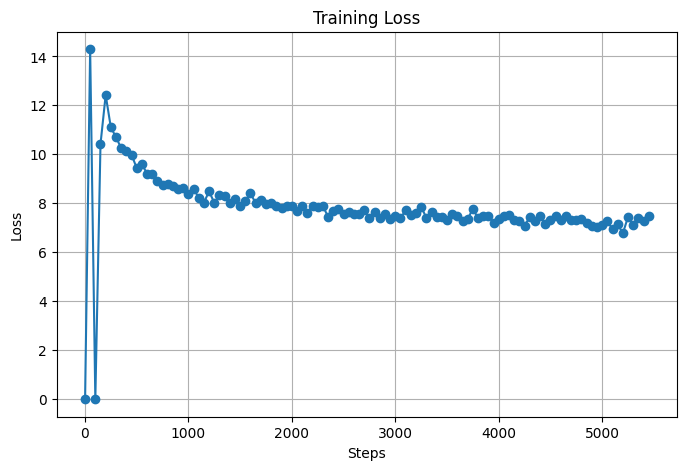

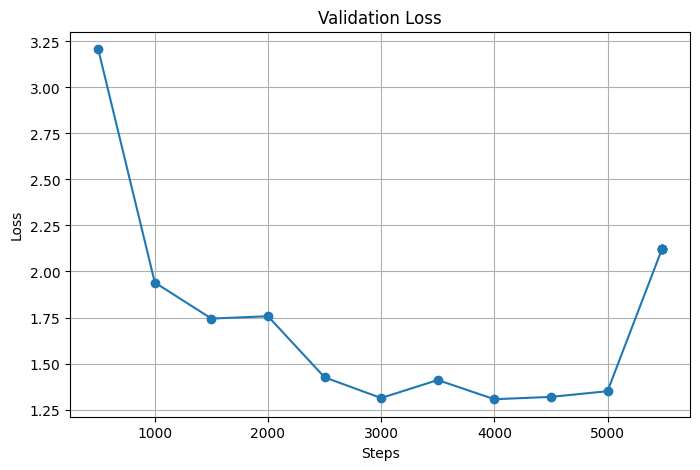

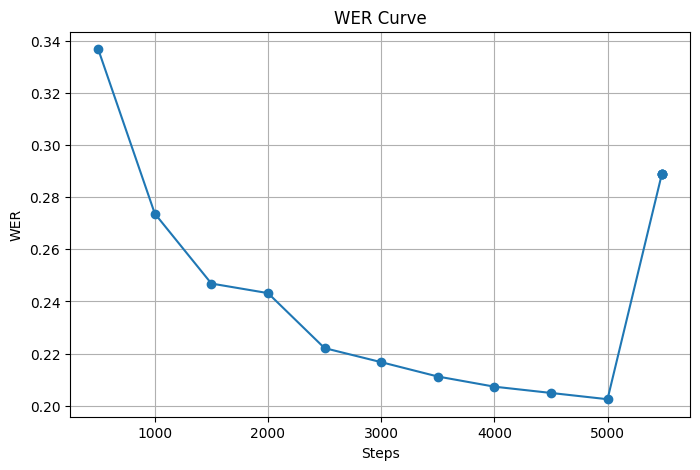

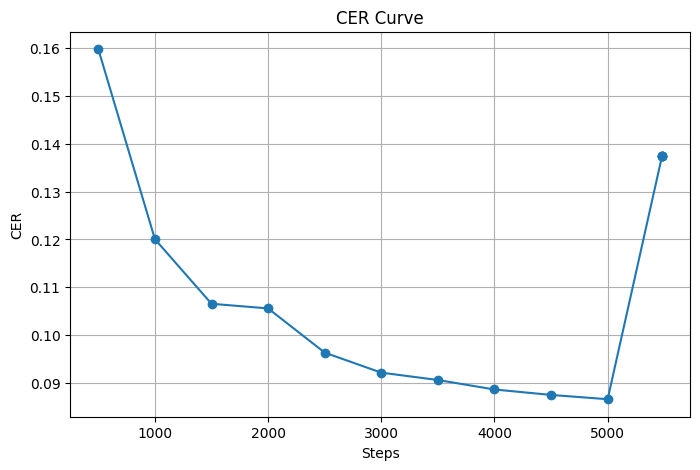

In [30]:
# ============================================================
# PART 13 : TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt

history = trainer.state.log_history

train_steps = []
train_loss = []

eval_steps = []
eval_loss = []

wer_steps = []
wer_values = []

cer_steps = []
cer_values = []

for log in history:

    if "loss" in log and "eval_loss" not in log:
        train_steps.append(log["step"])
        train_loss.append(log["loss"])

    if "eval_loss" in log:
        eval_steps.append(log["step"])
        eval_loss.append(log["eval_loss"])

    if "eval_wer" in log:
        wer_steps.append(log["step"])
        wer_values.append(log["eval_wer"])

    if "eval_cer" in log:
        cer_steps.append(log["step"])
        cer_values.append(log["eval_cer"])


# ---------------- Training Loss ----------------

plt.figure(figsize=(8,5))
plt.plot(train_steps, train_loss, marker="o")
plt.title("Training Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# ---------------- Validation Loss ----------------

if len(eval_loss)>0:
    plt.figure(figsize=(8,5))
    plt.plot(eval_steps, eval_loss, marker="o")
    plt.title("Validation Loss")
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

# ---------------- WER Curve ----------------

if len(wer_values)>0:
    plt.figure(figsize=(8,5))
    plt.plot(wer_steps, wer_values, marker="o")
    plt.title("WER Curve")
    plt.xlabel("Steps")
    plt.ylabel("WER")
    plt.grid(True)
    plt.show()

# ---------------- CER Curve ----------------

if len(cer_values)>0:
    plt.figure(figsize=(8,5))
    plt.plot(cer_steps, cer_values, marker="o")
    plt.title("CER Curve")
    plt.xlabel("Steps")
    plt.ylabel("CER")
    plt.grid(True)
    plt.show()

In [31]:
# ============================================================
# PART 14 : TEST RESULTS TABLE
# ============================================================

import pandas as pd

results = trainer.evaluate(test_dataset)

results_df = pd.DataFrame({

    "Metric":[
        "Test Loss",
        "WER",
        "CER",
        "Runtime (sec)",
        "Samples/sec"
    ],

    "Value":[
        results.get("eval_loss"),
        results.get("eval_wer"),
        results.get("eval_cer"),
        results.get("eval_runtime"),
        results.get("eval_samples_per_second")
    ]

})

print(results_df)

results_df.to_csv(
    "test_results.csv",
    index=False
)

          Metric       Value
0      Test Loss    2.120129
1            WER    0.288938
2            CER    0.137368
3  Runtime (sec)  344.866600
4    Samples/sec   36.565000
